In [11]:
import subprocess
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

SEED = 7
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
print("Torch version:", torch.__version__)

Device: cuda
Torch version: 2.8.0+cu128


In [24]:
USE_EASY_DATA = True

if USE_EASY_DATA:
    data_dir = Path("Data_EM_easy")
    nt_steps = 400
    cfl_value = 0.25
    extra_flags = ["--easy"]
    TARGET_IDX = 2
else:
    data_dir = Path("Data_EM")
    nt_steps = 600
    cfl_value = 0.45
    extra_flags = []
    TARGET_IDX = 4

INPUT_IDX = 1

required_files = [
    data_dir / "data_train_128.npy",
    data_dir / "data_val_128.npy",
    data_dir / "data_test_128.npy",
    data_dir / "data_test_unknown_128.npy",
    data_dir / "eps_train_128.npy",
    data_dir / "eps_val_128.npy",
    data_dir / "eps_test_128.npy",
    data_dir / "eps_test_unknown_128.npy",
    data_dir / "data_train_32.npy",
    data_dir / "data_val_32.npy",
    data_dir / "data_test_32.npy",
    data_dir / "eps_train_32.npy",
    data_dir / "eps_val_32.npy",
    data_dir / "eps_test_32.npy",
    data_dir / "data_train_64.npy",
    data_dir / "data_val_64.npy",
    data_dir / "data_test_64.npy",
    data_dir / "eps_train_64.npy",
    data_dir / "eps_val_64.npy",
    data_dir / "eps_test_64.npy",
    data_dir / "data_train_96.npy",
    data_dir / "data_val_96.npy",
    data_dir / "data_test_96.npy",
    data_dir / "eps_train_96.npy",
    data_dir / "eps_val_96.npy",
    data_dir / "eps_test_96.npy",
]

if not all(p.exists() for p in required_files):
    cmd = [
        "python",
        "em_fdtd_data.py",
        "--output-dir",
        str(data_dir),
        "--nx",
        "128",
        "--nt",
        str(nt_steps),
        "--snapshots",
        "5",
        "--cfl",
        str(cfl_value),
        "--seed",
        str(SEED),
    ] + extra_flags
    print("Running:", " ".join(cmd))
    subprocess.run(cmd, check=True)
else:
    print("Data already present")

print(f"Task 1 mapping: snapshot {INPUT_IDX} -> snapshot {TARGET_IDX}")

Data already present
Task 1 mapping: snapshot 1 -> snapshot 2


In [13]:
raw_data_train_128 = np.load(data_dir / "data_train_128.npy")
raw_data_val_128 = np.load(data_dir / "data_val_128.npy")
raw_data_test_128 = np.load(data_dir / "data_test_128.npy")
raw_data_test_unknown_128 = np.load(data_dir / "data_test_unknown_128.npy")

eps_train_128 = np.load(data_dir / "eps_train_128.npy")
eps_val_128 = np.load(data_dir / "eps_val_128.npy")
eps_test_128 = np.load(data_dir / "eps_test_128.npy")
eps_test_unknown_128 = np.load(data_dir / "eps_test_unknown_128.npy")

print("dataset dir:", data_dir)
print("train:", raw_data_train_128.shape, eps_train_128.shape)
print("val:", raw_data_val_128.shape, eps_val_128.shape)
print("test:", raw_data_test_128.shape, eps_test_128.shape)
print("test_unknown:", raw_data_test_unknown_128.shape, eps_test_unknown_128.shape)

dataset dir: Data_EM_easy
train: (800, 5, 128) (800, 128)
val: (120, 5, 128) (120, 128)
test: (120, 5, 128) (120, 128)
test_unknown: (120, 5, 128) (120, 128)


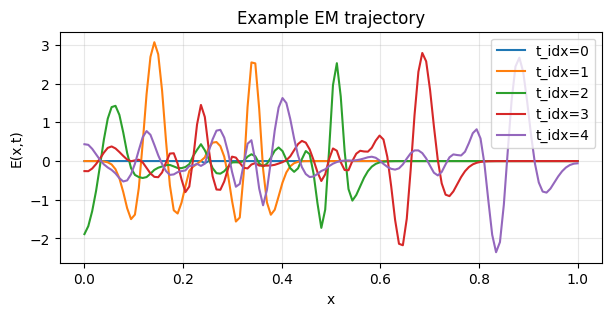

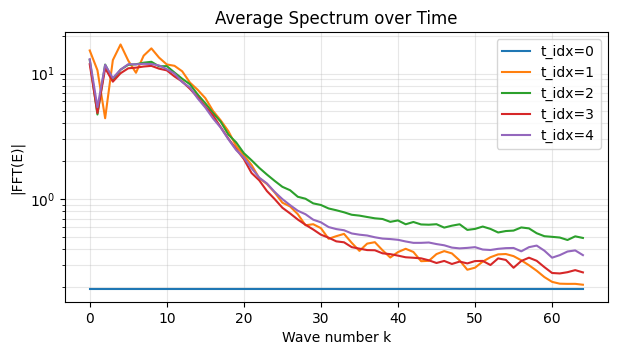

In [14]:
def plot_random_trajectory(data, title="Example EM trajectory"):
    plt.figure(figsize=(7, 3))
    idx = np.random.randint(len(data))
    t_steps = data.shape[1]
    x = np.linspace(0, 1, data.shape[-1])
    for i in range(t_steps):
        plt.plot(x, data[idx, i], label=f"t_idx={i}", lw=1.5)
    plt.xlabel("x")
    plt.ylabel("E(x,t)")
    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()


def plot_spectrum(data, title="Average Spectrum over Time"):
    plt.figure(figsize=(7, 3.5))
    num_t = data.shape[1]
    for i in range(num_t):
        e_t = data[:, i, :]
        e_t_ft = np.fft.rfft(e_t, axis=-1)
        mag = np.mean(np.abs(e_t_ft), axis=0)
        plt.semilogy(np.arange(len(mag)), mag, label=f"t_idx={i}")
    plt.xlabel("Wave number k")
    plt.ylabel("|FFT(E)|")
    plt.title(title)
    plt.legend()
    plt.grid(True, which="both", alpha=0.3)
    plt.show()


plot_random_trajectory(raw_data_train_128)
plot_spectrum(raw_data_train_128)

In [15]:
class SpectralConv1d(nn.Module):
    def __init__(self, in_channels, out_channels, modes):
        super().__init__()
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.modes = modes
        self.scale = 1 / (in_channels * out_channels)
        self.weights = nn.Parameter(
            self.scale * torch.rand(in_channels, out_channels, self.modes, dtype=torch.cfloat)
        )

    def complex_mult_1d(self, inp, weights):
        return torch.einsum("bix,iox->box", inp, weights)

    def forward(self, x):
        batchsize = x.shape[0]
        x_ft = torch.fft.rfft(x)
        out_ft = torch.zeros(
            batchsize,
            self.out_channels,
            x.size(-1) // 2 + 1,
            dtype=torch.cfloat,
            device=x.device,
        )
        out_ft[:, :, : self.modes] = self.complex_mult_1d(x_ft[:, :, : self.modes], self.weights)
        return torch.fft.irfft(out_ft, n=x.size(-1))


class FNO1d(nn.Module):
    def __init__(self, channels, modes, width, hidden_layers):
        super().__init__()
        self.linear_left = nn.Linear(channels, width)
        self.spectral_layers = nn.ModuleList([SpectralConv1d(width, width, modes) for _ in range(hidden_layers)])
        self.linear_inner_layers = nn.ModuleList([nn.Conv1d(width, width, 1) for _ in range(hidden_layers)])
        self.linear_right1 = nn.Linear(width, 32)
        self.linear_right2 = nn.Linear(32, 1)
        self.activation = nn.Tanh()

    def forward(self, x):
        x = x.permute(0, 2, 1)
        x = self.activation(self.linear_left(x))
        x = x.permute(0, 2, 1)

        for spectral_layer, linear_layer in zip(self.spectral_layers, self.linear_inner_layers):
            x = self.activation(spectral_layer(x) + linear_layer(x))

        x = x.permute(0, 2, 1)
        x = self.activation(self.linear_right1(x))
        x = self.linear_right2(x)
        return x.permute(0, 2, 1)

In [16]:
def prepare_data(data, time_idx, add_x=True, dt=None, output_idx=None, eps_data=None):
    samples, x_resolution = data.shape[0], data.shape[2]

    channels = 1
    add_t = dt is not None
    add_eps = eps_data is not None

    if add_eps:
        channels += 1
    if add_x:
        channels += 1
        x_channel = np.linspace(0, 1, x_resolution)
    if add_t:
        channels += 1
        t_channel = dt * np.ones(x_resolution)

    data_transformed = np.zeros((samples, channels, x_resolution), dtype=np.float32)
    channel_idx = 0
    data_transformed[:, channel_idx, :] = data[:, time_idx, :]
    channel_idx += 1

    if add_eps:
        data_transformed[:, channel_idx, :] = eps_data
        channel_idx += 1
    if add_x:
        data_transformed[:, channel_idx, :] = x_channel
        channel_idx += 1
    if add_t:
        data_transformed[:, channel_idx, :] = t_channel

    input_tensor = torch.from_numpy(data_transformed).float()

    if output_idx is not None:
        target_tensor = torch.from_numpy(data[:, output_idx : output_idx + 1, :]).float()
        return TensorDataset(input_tensor, target_tensor)

    return input_tensor


def prepare_all2all_dataset(data, time_steps=None, eps_data=None):
    all_inputs = []
    all_targets = []
    num_snapshots = data.shape[1]
    t_vals = np.linspace(0.0, 1.0, num_snapshots)

    if time_steps is None:
        for i in range(1, num_snapshots):
            for j in range(i, num_snapshots):
                current_dt = float(t_vals[j] - t_vals[i])
                x_inp = prepare_data(data, time_idx=i, add_x=True, dt=current_dt, eps_data=eps_data)
                y_tar = torch.from_numpy(data[:, j : j + 1, :]).float()
                all_inputs.append(x_inp)
                all_targets.append(y_tar)
    else:
        i = 1
        for dt, j in sorted(time_steps.items(), key=lambda kv: kv[0]):
            x_inp = prepare_data(data, time_idx=i, add_x=True, dt=float(dt), eps_data=eps_data)
            y_tar = torch.from_numpy(data[:, j : j + 1, :]).float()
            all_inputs.append(x_inp)
            all_targets.append(y_tar)

    return TensorDataset(torch.cat(all_inputs, dim=0), torch.cat(all_targets, dim=0))

In [17]:
def get_l2_error(model, dataset, batch_size=20, has_dt=False):
    model.eval()
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
    num = 0.0
    den = 0.0
    with torch.no_grad():
        for batch in loader:
            if has_dt:
                x_batch, y_batch = batch[0], batch[1]
            else:
                x_batch, y_batch = batch
            x_batch = x_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)
            pred = model(x_batch)
            num += torch.sum((pred - y_batch) ** 2).item()
            den += torch.sum(y_batch ** 2).item()
    model.train()
    return float(np.sqrt(num / (den + 1e-12)))


def plot_histories(history_train, history_val, switch_epoch, title=""):
    plt.figure(figsize=(7, 3))
    plt.semilogy(history_train, label="Train")
    plt.semilogy(history_val, label="Validation")
    plt.axvline(x=switch_epoch, color="gray", linestyle="--", label="Adam -> L-BFGS")
    plt.xlabel("Iteration")
    plt.ylabel("Relative L2")
    plt.title(title)
    plt.legend()
    plt.grid(True, which="both", alpha=0.3)
    plt.show()


def fit(model, optimizer_adam, optimizer_lbfgs, scheduler, loss_fn, data_train, data_val, epochs, batch_size):
    history_train = []
    history_val = []

    train_loader = DataLoader(data_train, batch_size=batch_size, shuffle=True)

    model.to(DEVICE)

    for epoch in range(epochs):
        history_train.append(get_l2_error(model, data_train, batch_size=batch_size))
        history_val.append(get_l2_error(model, data_val, batch_size=batch_size))

        train_mse = 0.0
        for x_batch, y_batch in train_loader:
            x_batch = x_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)
            optimizer_adam.zero_grad()
            pred = model(x_batch)
            loss = loss_fn(pred, y_batch)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer_adam.step()
            train_mse += float(loss.item())

        train_mse /= max(1, len(train_loader))
        if epoch % 5 == 0:
            print(f"Epoch {epoch:03d} | train mse: {train_mse:.6f}")

        scheduler.step()

    x_train, y_train = data_train.tensors
    x_train = x_train.to(DEVICE)
    y_train = y_train.to(DEVICE)

    def closure():
        optimizer_lbfgs.zero_grad()
        pred = model(x_train)
        loss = loss_fn(pred, y_train)
        loss.backward()
        history_train.append(get_l2_error(model, data_train, batch_size=batch_size))
        history_val.append(get_l2_error(model, data_val, batch_size=batch_size))
        return loss

    optimizer_lbfgs.step(closure)
    return history_train, history_val

### One2one Training

Epoch 000 | train mse: 0.464462
Epoch 005 | train mse: 0.085348
Epoch 010 | train mse: 0.033299
Epoch 015 | train mse: 0.022900
Epoch 020 | train mse: 0.015447
Epoch 025 | train mse: 0.014641
Epoch 030 | train mse: 0.008929
Epoch 035 | train mse: 0.006363
Epoch 040 | train mse: 0.006165
Epoch 045 | train mse: 0.005338


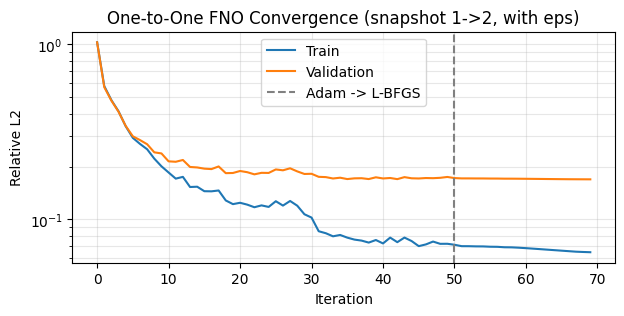

In [19]:
modes = 16
width = 64
hidden_layers = 4
learning_rate = 4e-3
epochs = 50
step_size = 30
gamma = 0.7
batch_size = 20

train_ds_raw = prepare_data(raw_data_train_128, time_idx=INPUT_IDX, output_idx=TARGET_IDX, eps_data=eps_train_128)
val_ds_raw = prepare_data(raw_data_val_128, time_idx=INPUT_IDX, output_idx=TARGET_IDX, eps_data=eps_val_128)

x_tr, y_tr = train_ds_raw.tensors
x_va, y_va = val_ds_raw.tensors

res_tr = y_tr - x_tr[:, 0:1, :]
res_va = y_va - x_va[:, 0:1, :]

x_field_mu = x_tr[:, 0:1, :].mean()
x_field_std = x_tr[:, 0:1, :].std().clamp_min(1e-6)
res_mu = res_tr.mean()
res_std = res_tr.std().clamp_min(1e-6)

x_tr_n = x_tr.clone()
x_va_n = x_va.clone()
x_tr_n[:, 0:1, :] = (x_tr_n[:, 0:1, :] - x_field_mu) / x_field_std
x_va_n[:, 0:1, :] = (x_va_n[:, 0:1, :] - x_field_mu) / x_field_std

train_ds = TensorDataset(x_tr_n, (res_tr - res_mu) / res_std)
val_ds = TensorDataset(x_va_n, (res_va - res_mu) / res_std)

channels = x_tr_n.shape[1]
fno = FNO1d(channels, modes, width, hidden_layers).to(DEVICE)
optimizer_adam = torch.optim.AdamW(fno.parameters(), lr=learning_rate, weight_decay=1e-4)
optimizer_lbfgs = torch.optim.LBFGS(
    fno.parameters(),
    lr=0.15,
    max_iter=20,
    max_eval=20,
    history_size=10,
    line_search_fn="strong_wolfe",
)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer_adam, step_size=step_size, gamma=gamma)
loss_fn = nn.MSELoss()

model_path_one2one = Path("fno_em_one2one.pth")
if model_path_one2one.exists():
    model_path_one2one.unlink()

h_train, h_val = fit(
    fno,
    optimizer_adam,
    optimizer_lbfgs,
    scheduler,
    loss_fn,
    train_ds,
    val_ds,
    epochs,
    batch_size,
)
torch.save(
    {
        "model_state_dict": fno.state_dict(),
        "history_train": h_train,
        "history_val": h_val,
        "x_field_mu": float(x_field_mu.detach().cpu().item()),
        "x_field_std": float(x_field_std.detach().cpu().item()),
        "res_mu": float(res_mu.detach().cpu().item()),
        "res_std": float(res_std.detach().cpu().item()),
        "input_idx": int(INPUT_IDX),
        "target_idx": int(TARGET_IDX),
        "channels": int(channels),
    },
    model_path_one2one,
)
plot_histories(h_train, h_val, epochs, title=f"One-to-One FNO Convergence (snapshot {INPUT_IDX}->{TARGET_IDX}, with eps)")

Example inference on test sample 0
Mapping: snapshot 1 -> snapshot 2
Sample relative L2 error: 0.2897


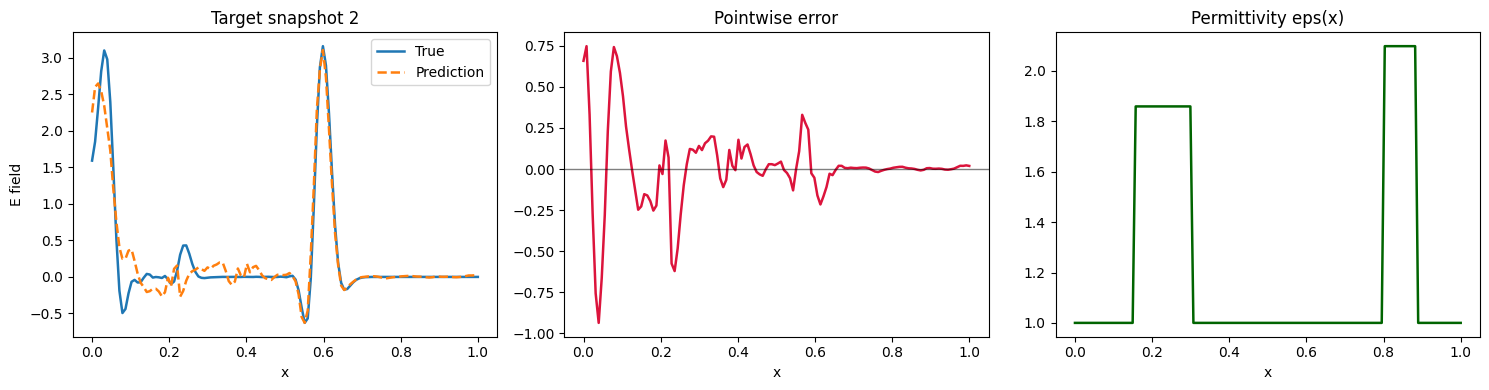

In [20]:
sample_idx = 0

ckpt = torch.load(model_path_one2one, map_location=DEVICE)
fno.load_state_dict(ckpt["model_state_dict"])
fno.eval()

x_field_mu = ckpt["x_field_mu"]
x_field_std = ckpt["x_field_std"]
res_mu = ckpt["res_mu"]
res_std = ckpt["res_std"]
input_idx = int(ckpt.get("input_idx", 1))
target_idx = int(ckpt.get("target_idx", 4))

inp_np = raw_data_test_128[sample_idx, input_idx, :]
eps_np = eps_test_128[sample_idx]
true_np = raw_data_test_128[sample_idx, target_idx, :]
x_grid = np.linspace(0, 1, inp_np.shape[0])

inp_raw = torch.tensor(inp_np, dtype=torch.float32).unsqueeze(0).unsqueeze(-1).to(DEVICE)
eps_raw = torch.tensor(eps_np, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(DEVICE)
xcoord = torch.tensor(x_grid, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(DEVICE)
x_in = torch.cat([inp_raw.permute(0, 2, 1), eps_raw, xcoord], dim=1)

x_model = x_in.clone()
x_model[:, 0:1, :] = (x_model[:, 0:1, :] - x_field_mu) / (x_field_std + 1e-12)

with torch.no_grad():
    dE_pred_n = fno(x_model)
    dE_pred = dE_pred_n * res_std + res_mu
    pred_np = (x_in[:, 0:1, :] + dE_pred).squeeze().cpu().numpy()

sample_rel_l2 = np.linalg.norm(pred_np - true_np) / (np.linalg.norm(true_np) + 1e-12)
error_np = pred_np - true_np

print(f"Example inference on test sample {sample_idx}")
print(f"Mapping: snapshot {input_idx} -> snapshot {target_idx}")
print(f"Sample relative L2 error: {sample_rel_l2:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=True)
axes[0].plot(x_grid, true_np, label="True", lw=1.8)
axes[0].plot(x_grid, pred_np, "--", label="Prediction", lw=1.8)
axes[0].set_title(f"Target snapshot {target_idx}")
axes[0].set_xlabel("x")
axes[0].set_ylabel("E field")
axes[0].legend()

axes[1].plot(x_grid, error_np, color="crimson", lw=1.8)
axes[1].axhline(0.0, color="black", lw=1.0, alpha=0.5)
axes[1].set_title("Pointwise error")
axes[1].set_xlabel("x")

axes[2].plot(x_grid, eps_np, color="darkgreen", lw=1.8)
axes[2].set_title("Permittivity eps(x)")
axes[2].set_xlabel("x")

plt.tight_layout()
plt.show()